# Optimización de dieta: costo mínimo y cobertura con presupuesto

Dos experimentos de programación lineal (LP) para **una persona y un día**, con el
catálogo CBA–INCAP y los requerimientos calculados por el proyecto:

1. **Costo mínimo:** ¿cuánto cuesta satisfacer todos los requisitos modelados?
2. **Cobertura máxima:** ¿qué proporción de esos requisitos puede alcanzarse con un presupuesto dado?


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from canasta_inteligente.application.cba_pipeline import load_catalog_pickle

catalog_path = PROJECT_ROOT / 'data' / 'processed' / 'cba_catalog.pkl'
if not catalog_path.exists():
    raise FileNotFoundError(
        f'No existe {catalog_path}. Ejecuta primero cba_pipeline.ipynb '
        'o el módulo canasta_inteligente.application.cba_pipeline.'
    )
catalog = load_catalog_pickle(catalog_path)
print(f'Catálogo: {catalog_path.resolve()}')
print(f'Alimentos disponibles: {len(catalog)}')
print(f'Con información nutricional: {sum(food.nutrition is not None for food in catalog)}')

Catálogo: C:\Users\lp109\Projects\canasta-inteligente-gt\data\processed\cba_catalog.pkl
Alimentos disponibles: 72
Con información nutricional: 72


## Perfil y requerimientos diarios

Se conserva el perfil de referencia del notebook: hombre de 25 años, 65 kg, 1.70 m
y actividad física baja. Modificarlo antes de ejecutar los modelos para evaluar otra persona.

In [2]:
from canasta_inteligente.domain.persona import Persona
from canasta_inteligente.nutrition.evaluation import Peso
from canasta_inteligente.nutrition.service import evaluacion_de_requerimientos_diarios

hombre_promedio = Persona(
    nombre='Hombre promedio de 25 años', edad=25, sexo='hombre',
    peso=78, altura=1.72, naf='moderada',
)
requerimientos = evaluacion_de_requerimientos_diarios(hombre_promedio)
evaluacion_peso = Peso.evaluacion_peso(hombre_promedio)
print(f'Perfil: {hombre_promedio.nombre}')
print(f'IMC: {evaluacion_peso["valor_de_indicador"]:.2f} kg/m²')
print(f'Estado antropométrico: {evaluacion_peso["estado_de_indicador"]}')
print(f'Peso usado en los cálculos: {evaluacion_peso["peso_para_calculos"]:.1f} kg')

Perfil: Hombre promedio de 25 años
IMC: 26.37 kg/m²
Estado antropométrico: sobrepeso
Peso usado en los cálculos: 65.1 kg


In [3]:
requerimientos

{'energia': {'ree': 3678.8000339200003, 'unidad': 'kCal'},
 'proteina': {'rpe': 42.95596799999999,
  'rdd_referencia': 54.020383999999986,
  'rdd_dieta_mixta': 72.89497599999999,
  'unidad': 'g'},
 'carbohidratos': {'ia': None,
  'rpe': 100,
  'rdd_min': 505.83500466400005,
  'rdd_max': 643.7900059360001,
  'unidad': 'g'},
 'azucar': {'ia': None, 'rpe': None, 'rdd': 91.97000084800001, 'unidad': 'g'},
 'fibra': {'ia': None, 'rpe': None, 'rdd': 44.14560040704001, 'unidad': 'g'},
 'lipidos': {'total_min': 81.7511118648889,
  'total_max': 122.62666779733334,
  'saturados_max': 40.87555593244445,
  'poliinsaturados_min': 24.525333559466667,
  'poliinsaturados_max': 44.963111525688895,
  'trans_max': 4.087555593244445,
  'unidad': 'g'},
 'colesterol': {'maximo': 300, 'unidad': 'mg'},
 'micronutrientes': {'vitamina_a': {'rpe': 525,
   'rdd': 750,
   'ia': None,
   'unidad': 'mcg EAR'},
  'retinol': {'imt': 3000, 'unidad': 'mcg'},
  'tiamina': {'ia': None, 'rpe': 1, 'rdd': 1.2, 'unidad': 'mg'}

In [4]:
requerimientos["minerales"]

{'calcio': {'ia': 1000, 'imt': 2500, 'rpe': None, 'rdd': None, 'unidad': 'mg'},
 'fosforo': {'ia': None, 'rpe': 580, 'rdd': 700, 'unidad': 'mg'},
 'magnesio': {'ia': None,
  'rpe': 260.33919999999995,
  'rdd': 312.40703999999994,
  'unidad': 'mg'},
 'hierro': {'alta_biodisponibilidad': {'ia': None, 'rpe': 5.7, 'rdd': 7.5},
  'media_biodisponibilidad': {'ia': None, 'rpe': 8.6, 'rdd': 11.2},
  'baja_biodisponibilidad': {'ia': None, 'rpe': 17.2, 'rdd': 22.4},
  'unidad': 'mg'},
 'zinc': {'alta_biodisponibilidad': {'ia': None, 'rpe': 8.8, 'rdd': 10.6},
  'baja_biodisponibilidad': {'ia': None, 'rpe': 17.7, 'rdd': 21.2},
  'unidad': 'mg',
  'imt': 40},
 'cobre': {'ia': None, 'rpe': 700, 'rdd': 900, 'unidad': 'mcg', 'imt': 10000},
 'selenio': {'ia': None, 'rpe': 45, 'rdd': 54, 'unidad': 'mcg', 'imt': 400}}

# Minimizaccion de costo para total cobertura de requerimientos nutricionales


In [5]:
from pulp import *

In [6]:
from pulp import *
import pandas as pd
from copy import deepcopy
from math import isfinite


def construir_restricciones_base(requerimientos):
    """Traduce los requisitos de este perfil a nutrientes del catalogo."""
    escalar = lambda valor, divisor: None if valor is None else valor / divisor
    get_min_req = lambda nutrient, subrequerimientos: subrequerimientos[nutrient].get('rdd') if subrequerimientos[nutrient].get('rdd') is not None else subrequerimientos[nutrient].get('ia') 
    # ct = close to 
    constraints_keys_base = {
        'energia_kcal': {"ct": requerimientos['energia']['ree']},
        'proteina_g': {"min": requerimientos['proteina']['rdd_dieta_mixta']},
        'carbohidratos_g': {"min": requerimientos['carbohidratos']['rdd_min']},
        'azucares_g': {"max": requerimientos["azucar"]["rdd"]},
        'fibra_dietetica_g': {"min": requerimientos["fibra"]['rdd']},
        'grasa_total_g': {"min": requerimientos["lipidos"]["total_min"], 'max': requerimientos['lipidos']['total_max']},
        'ag_sat_g': {"max": requerimientos["lipidos"]['saturados_max']},
        'ag_poli_g': {"min": requerimientos["lipidos"]["poliinsaturados_min"], 'max': requerimientos["lipidos"]["poliinsaturados_max"]},
        'colesterol_mg': {"ct": requerimientos['colesterol']["maximo"]},
        'vitamina_a_rae_mcg': {"min": get_min_req('vitamina_a', requerimientos["micronutrientes"])},
        'retinol_mcg': {"max": requerimientos['micronutrientes']['retinol']['imt']},
        'tiamina_mg': {"min": get_min_req('tiamina', requerimientos["micronutrientes"]) },
        'riboflavina_mg': {"min": get_min_req('riboflavina', requerimientos["micronutrientes"]) },
        'niacina_mg': {"min": get_min_req('niacina', requerimientos["micronutrientes"]) },
        'vitamina_b6_mg': {"min": get_min_req('vitamina_b6', requerimientos["micronutrientes"]), 'max': requerimientos['micronutrientes']['vitamina_b6']['imt']},
        'folato_fde_mcg': {"min": get_min_req('folatos', requerimientos["micronutrientes"])},
        'ac_folico_mcg': {"max": requerimientos['micronutrientes']["folato_sintetico"]["imt"]},
        'vitamina_b12_mcg': {'min': get_min_req('vitamina_b12', requerimientos["micronutrientes"])},
        'ac_pantotenico_mg': {'min': get_min_req('acido_pantotenico', requerimientos["micronutrientes"])},
        'vitamina_c_mg': {"min": get_min_req('vitamina_c', requerimientos["micronutrientes"])},
        'vitamina_d_mcg': {"min": get_min_req('vitamina_d', requerimientos["micronutrientes"]), "max": requerimientos['micronutrientes']['vitamina_d']['imt']},
        'vitamina_e_mg': {"min": get_min_req('vitamina_e', requerimientos["micronutrientes"]), "max": requerimientos['micronutrientes']['vitamina_e']['imt']},
        'vitamina_k_mcg': {"min": get_min_req("vitamina_k", requerimientos["micronutrientes"])},
        'calcio_mg': {"min": get_min_req("calcio", requerimientos["minerales"]), "max":  requerimientos['minerales']['calcio']['imt']},
        'magnesio_mg': {"min": get_min_req("magnesio", requerimientos["minerales"])},
        'fosforo_mg': {"min": get_min_req("fosforo", requerimientos["minerales"])},
        'selenio_mcg': {"min": get_min_req("selenio", requerimientos["minerales"]), "max":  requerimientos['minerales']['selenio']['imt']},
        'cobre_mg': {"min": escalar(get_min_req("cobre", requerimientos["minerales"]), 1000), "max":  escalar(requerimientos['minerales']['cobre']['imt'], 1000)},
        'zinc_mg':{"min": get_min_req("baja_biodisponibilidad", requerimientos['minerales']['zinc'])}, # Asumimos baja biodisponibildiad  dados los multiples factores que afecta la aborcion del zinc. 
        'potasio_mg': {"min": get_min_req("potasio", requerimientos["electrolitos"])},
        'sodio_mg': {"min": get_min_req("sodio", requerimientos["electrolitos"]), "max":  requerimientos["electrolitos"]['sodio']['limite_sugerido']},
    }



    hierro_constraints = {
        'baja_disponiblidad': {
            "hierro_mg": {'min': get_min_req("baja_biodisponibilidad", requerimientos['minerales']['hierro'])},
            "vitamina_c_mg": {'min': 0.00},
            'carne_g': {'min': 0.00}
        },# Sin restricciones
        'media_disponiblidad': {
            "hierro_mg": {'min': get_min_req("media_biodisponibilidad", requerimientos['minerales']['hierro'])},
            "vitamina_c_mg": { 'min': 25, 'max': 75 },
            'carne_g': {'min': 0.30, 'max': 0.90}
        
        },

        'alta_disponiblidad_A': {
            "hierro_mg": {'min': get_min_req("alta_biodisponibilidad", requerimientos['minerales']['hierro'])},
            "vitamina_c_mg": { 'min': 25, 'max': 75 },
            'carne_g': {'min': 0.3}

        },
        'alta_disponiblidad_B': {
            "hierro_mg": {'min': get_min_req("alta_biodisponibilidad", requerimientos['minerales']['hierro'])},
            "vitamina_c_mg": {'min': 25},
            'carne_g': {'min': 0.9}

        },
    }
    # None significa que el evaluador no proporciona ese limite para este perfil.
    for limites in constraints_keys_base.values():
        for tipo, valor in list(limites.items()):
            if valor is None:
                del limites[tipo]
    return constraints_keys_base, hierro_constraints


def combinar_escenarios(base, hierro, maximizar=False):
    """Combina las condiciones de hierro sin modificar las entradas."""
    escenarios = {}
    for nombre, condiciones in hierro.items():
        restricciones = deepcopy(base)
        if maximizar:
            for limites in restricciones.values():
                if 'min' in limites:
                    limites['meta'] = limites.pop('min')
        restricciones['hierro_mg'] = {
            'meta' if maximizar else 'min': condiciones['hierro_mg']['min'],
        }
        restricciones['carne_g'] = deepcopy(condiciones['carne_g'])
        vitamina_c = restricciones['vitamina_c_mg']
        for tipo, valor in condiciones['vitamina_c_mg'].items():
            combinar = max if tipo == 'min' else min
            vitamina_c[tipo] = combinar(vitamina_c.get(tipo, valor), valor)
        # Conservar los escenarios incompatibles para reportarlos como Infeasible.
        escenarios[f'hierro_{nombre}'] = restricciones
    return escenarios


def construir_escenarios(requerimientos, maximizar=False):
    base, hierro = construir_restricciones_base(requerimientos)
    return combinar_escenarios(base, hierro, maximizar=maximizar)


constraints_keys_base, hierro_constraints = construir_restricciones_base(requerimientos)
possible_constraints = combinar_escenarios(constraints_keys_base, hierro_constraints)


In [7]:
possible_constraints

{'hierro_baja_disponiblidad': {'energia_kcal': {'ct': 3678.8000339200003},
  'proteina_g': {'min': 72.89497599999999},
  'carbohidratos_g': {'min': 505.83500466400005},
  'azucares_g': {'max': 91.97000084800001},
  'fibra_dietetica_g': {'min': 44.14560040704001},
  'grasa_total_g': {'min': 81.7511118648889, 'max': 122.62666779733334},
  'ag_sat_g': {'max': 40.87555593244445},
  'ag_poli_g': {'min': 24.525333559466667, 'max': 44.963111525688895},
  'colesterol_mg': {'ct': 300},
  'vitamina_a_rae_mcg': {'min': 750},
  'retinol_mcg': {'max': 3000},
  'tiamina_mg': {'min': 1.2},
  'riboflavina_mg': {'min': 1.3},
  'niacina_mg': {'min': 16},
  'vitamina_b6_mg': {'min': 1.3, 'max': 100},
  'folato_fde_mcg': {'min': 400},
  'ac_folico_mcg': {'max': 1000},
  'vitamina_b12_mcg': {'min': 2.4},
  'ac_pantotenico_mg': {'min': 5.0},
  'vitamina_c_mg': {'min': 75},
  'vitamina_d_mcg': {'min': 5, 'max': 50},
  'vitamina_e_mg': {'min': 15, 'max': 1000},
  'vitamina_k_mcg': {'min': 65.08479999999999},


In [8]:
catalog.get('arroz').price_summary(region='general')['latest'].cost_per_gram * 100

1.857142731277533

In [9]:
catalog_variables = [[_food_item, LpVariable(name=f'no_portions_{_food_item.id}', lowBound=0)] for _food_item in catalog]

for _cat_item in catalog_variables:
    aporte = _cat_item[0].nutrition.values_per_100g['fraccion_comestible_pct']
    print(aporte)

1.0
1.0
1.0
1.0
1.0
1.0
0.95
0.56
0.75
0.68
1.0
1.0
1.0
1.0
1.0
0.88
1.0
0.67
0.64
0.65
0.51
0.52
0.91
0.77
0.96
0.75
0.82
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.8
0.85
0.82
1.0
1.0
0.6
0.73
0.89
1.0
1.0
0.68
0.98
0.51
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.67
1.0
0.95
0.89
1.0
0.62
1.0
1.0
1.0
0.56
1.0
1.0
1.0
1.0


In [10]:
from copy import deepcopy
get_latest_price_any_region = lambda _food_item : _food_item.price_summary(region='general')['latest'].cost_per_gram if _food_item.price_summary(region='general')['latest'] is not None else (_food_item.price_summary(region='urbana')['latest'].cost_per_gram if _food_item.price_summary(region='urbana')['latest'] is not None else  _food_item.price_summary(region='rural')['latest'].cost_per_gram)


def extraer_resultado(escenario, modelo, catalog_variables, restricciones,
                     desviaciones, penalizaciones):
    """Guarda una instantánea numérica y las referencias al modelo resuelto."""
    es_optimo = modelo.status == LpStatusOptimal
    filas = []
    if es_optimo:
        for food, variable in catalog_variables:
            porciones = variable.varValue
            gramos = porciones * 100
            precio = get_latest_price_any_region(food)
            filas.append({
                'alimento_id': food.id, 'alimento': food.name,
                'porciones_100g': porciones, 'gramos': gramos,
                'precio_q_por_gramo': precio, 'costo_q': gramos * precio,
            })

    alimentos = pd.DataFrame(filas, columns=[
        'alimento_id', 'alimento', 'porciones_100g', 'gramos',
        'precio_q_por_gramo', 'costo_q',
    ])
    aportes = {}
    if es_optimo:
        for nutriente in restricciones:
            # El modelo usa porciones de 100 g para carne_g; aquí mostramos gramos.
            aportes[nutriente] = sum(
                variable.varValue * (100 * food.is_meat if nutriente == 'carne_g'
                                     else food[nutriente])
                * food.nutrition.values_per_100g['fraccion_comestible_pct']
                for food, variable in catalog_variables
            )

    diagnostico = pd.DataFrame([
        {
            'restriccion': nombre,
            'expresion': str(restriccion),
            'holgura_solver': restriccion.slack if es_optimo else None,
            'precio_sombra': restriccion.pi if es_optimo else None,
        }
        for nombre, restriccion in modelo.constraints.items()
    ])
    return {
        'escenario': escenario,
        'estado': LpStatus[modelo.status],
        'codigo_estado': modelo.status,
        'costo_total_q': float(alimentos['costo_q'].sum()) if es_optimo else None,
        'valor_objetivo': value(modelo.objective) if es_optimo else None,
        'desviaciones': {
            nombre: variable.varValue if es_optimo else None
            for nombre, variable in desviaciones.items()
        },
        'penalizaciones': penalizaciones.copy(),
        'alimentos': alimentos,
        'aportes': pd.Series(aportes, dtype=float, name='aporte_total'),
        'restricciones': deepcopy(restricciones),
        'diagnostico_restricciones': diagnostico,
        'modelo': modelo,
        'variables': {food.id: variable for food, variable in catalog_variables},
    }


def mostrar_resultado(resultado, tolerancia=1e-6):
    """Muestra un resultado guardado sin volver a resolver el problema."""
    print(f"Escenario: {resultado['escenario']}")
    print(f"Estado: {resultado['estado']}")
    if resultado['estado'] != 'Optimal':
        print('No se encontró una solución óptima; no se reportan cantidades ni costos.')
        return

    alimentos = resultado['alimentos']
    display(alimentos.loc[alimentos['porciones_100g'] > tolerancia].round(4))
    print(f"Costo total: Q {resultado['costo_total_q']:.2f}")
    if 'energia_deficit_kcal' in resultado['desviaciones']:
        print(f"Energía por debajo: {resultado['desviaciones']['energia_deficit_kcal']:.2f} kcal")
    if 'energia_exceso_kcal' in resultado['desviaciones']:
        print(f"Energía por encima: {resultado['desviaciones']['energia_exceso_kcal']:.2f} kcal")
    if 'colesterol_exceso_mg' in resultado['desviaciones']:
        print(f"Exceso colesterol: {resultado['desviaciones']['colesterol_exceso_mg']:.2f} mg")
    print(f"Valor función objetivo: {resultado['valor_objetivo']:.4f}")
    if 'coberturas' in resultado:
        print(f"Presupuesto diario: Q {resultado['presupuesto_q']:.2f}")
        print(f"Cobertura media: {resultado['cobertura_media_pct']:.2f} %")
        print(f"Cobertura ponderada: {resultado['cobertura_ponderada_pct']:.2f} %")
        print(f"Penalizacion total: {resultado['penalizacion_total']:.4f}")
        display(resultado['coberturas'].round(4))


In [11]:
from math import isfinite


def minimizar_costo(catalog, escenarios, penalizaciones=None):
    """Minimiza costo mas penalizaciones, con minimos y maximos obligatorios."""
    coeficientes = {'energia': 1.0, 'colesterol': 0.1}
    configuradas = dict(penalizaciones or {})
    desconocidas = set(configuradas) - set(coeficientes)
    if desconocidas:
        raise ValueError(f'Penalizaciones desconocidas: {sorted(desconocidas)}')
    coeficientes.update(configuradas)
    for nombre, coeficiente in coeficientes.items():
        try:
            coeficiente = float(coeficiente)
        except (TypeError, ValueError):
            raise ValueError(f'Penalizacion invalida para {nombre}: debe ser numerica.') from None
        if not isfinite(coeficiente) or coeficiente < 0:
            raise ValueError(f'Penalizacion invalida para {nombre}: debe ser finita y no negativa.')
        coeficientes[nombre] = coeficiente

    resultados = []
    for escenario, restricciones in escenarios.items():
        modelo = LpProblem(f"MinimizeCost_{escenario}", LpMinimize)
        variables = [
            (food, LpVariable(f'no_portions_{food.id}', lowBound=0))
            for food in catalog
        ]
        aportes = {}
        for nutriente in restricciones:
            if nutriente == 'carne_g':
                aportes[nutriente] = lpSum(
                    variable * food.nutrition.values_per_100g['fraccion_comestible_pct']
                    for food, variable in variables if food.is_meat
                )
            else:
                aportes[nutriente] = lpSum(
                    variable * food[nutriente]
                    * food.nutrition.values_per_100g['fraccion_comestible_pct']
                    for food, variable in variables
                )

        desviaciones = {}
        terminos_penalizacion = []
        for nutriente, limites in restricciones.items():
            if 'ct' in limites:
                referencia = limites['ct']
                if not isfinite(referencia) or referencia < 0:
                    raise ValueError(f'Referencia ct invalida para {nutriente}.')
                if nutriente == 'energia_kcal':
                    deficit = LpVariable('deEminus', lowBound=0)
                    exceso = LpVariable('deEplus', lowBound=0)
                    modelo += aportes[nutriente] + deficit - exceso == referencia, 'REE'
                    desviaciones['energia_deficit_kcal'] = deficit
                    desviaciones['energia_exceso_kcal'] = exceso
                    terminos_penalizacion.append(coeficientes['energia'] * (deficit + exceso))
                elif nutriente == 'colesterol_mg':
                    exceso = LpVariable('deCPlus', lowBound=0)
                    modelo += aportes[nutriente] - exceso <= referencia, 'Colesterol'
                    desviaciones['colesterol_exceso_mg'] = exceso
                    terminos_penalizacion.append(coeficientes['colesterol'] * exceso)
                else:
                    raise ValueError(f'Nutriente con referencia ct no admitido: {nutriente}')
            if 'min' in limites:
                modelo += aportes[nutriente] >= limites['min'], f'limite_inferior_de_{nutriente}'
            if 'max' in limites:
                modelo += aportes[nutriente] <= limites['max'], f'limite_superior_de_{nutriente}'

        costo = lpSum(
            variable * get_latest_price_any_region(food) * 100
            for food, variable in variables
        )
        modelo += costo + lpSum(terminos_penalizacion), 'costo_mas_penalizaciones'
        modelo.solve(PULP_CBC_CMD(msg=0))

        resultado = extraer_resultado(
            escenario, modelo, variables, restricciones,
            desviaciones=desviaciones, penalizaciones=coeficientes,
        )
        # Reportar desviaciones reales incluso si un coeficiente es cero:
        # en ese caso el solver no esta obligado a minimizar las holguras.
        if modelo.status == LpStatusOptimal:
            if 'energia_deficit_kcal' in desviaciones:
                diferencia = resultado['aportes']['energia_kcal'] - restricciones['energia_kcal']['ct']
                resultado['desviaciones']['energia_deficit_kcal'] = max(0.0, -diferencia)
                resultado['desviaciones']['energia_exceso_kcal'] = max(0.0, diferencia)
            if 'colesterol_exceso_mg' in desviaciones:
                resultado['desviaciones']['colesterol_exceso_mg'] = max(
                    0.0, resultado['aportes']['colesterol_mg'] - restricciones['colesterol_mg']['ct'],
                )
        resultado['penalizacion_total'] = (
            coeficientes['energia'] * (
                resultado['desviaciones'].get('energia_deficit_kcal', 0.0)
                + resultado['desviaciones'].get('energia_exceso_kcal', 0.0)
            ) + coeficientes['colesterol'] * resultado['desviaciones'].get('colesterol_exceso_mg', 0.0)
            if modelo.status == LpStatusOptimal else None
        )
        resultados.append(resultado)
    return resultados


lambda_co = 0.1
lambda_ree = 1
penalizaciones_minimizacion = {'energia': lambda_ree, 'colesterol': lambda_co}
catalog_variable_results = minimizar_costo(catalog, possible_constraints, penalizaciones_minimizacion)
lps = [resultado['modelo'] for resultado in catalog_variable_results]
for resultado_minimo in catalog_variable_results:
    mostrar_resultado(resultado_minimo)


Escenario: hierro_baja_disponiblidad
Estado: Optimal


,alimento_id,alimento,porciones_100g,gramos,precio_q_por_gramo,costo_q
11,leche_en_polvo,LECHE EN POLVO,0.4087,40.8687,0.0983,4.0185
16,aceites_comestibles,ACEITES COMESTIBLES,0.2507,25.0707,0.0265,0.6642
26,hierbas,HIERBAS,1.6365,163.6491,0.0160,2.6154
27,frijol,FRIJÓL,4.0977,409.7748,0.0165,6.7694
29,sal,SAL,0.0128,1.2775,0.0025,0.0032
34,harina_de_maiz,Harina de maíz,2.3764,237.6448,0.0144,3.4161
47,margarina_vegetal_regular,Margarina vegetal regular,0.8734,87.3445,0.0376,3.2863
59,cereales_de_bolsa_o_caja,Cereales de bolsa o caja,0.1969,19.6884,0.0510,1.0044
64,azucar_de_cana_morena,Azúcar de caña morena,0.6200,61.9980,0.0092,0.5719


Costo total: Q 22.35
Energía por debajo: 0.00 kcal
Energía por encima: 0.00 kcal
Exceso colesterol: 0.00 mg
Valor función objetivo: 22.3496
Escenario: hierro_media_disponiblidad
Estado: Optimal


,alimento_id,alimento,porciones_100g,gramos,precio_q_por_gramo,costo_q
4,fideos,FIDEOS,0.0020,0.2018,0.0220,0.0044
11,leche_en_polvo,LECHE EN POLVO,0.1146,11.4633,0.0983,1.1271
16,aceites_comestibles,ACEITES COMESTIBLES,0.1849,18.4915,0.0265,0.4899
26,hierbas,HIERBAS,0.7020,70.1961,0.0160,1.1219
27,frijol,FRIJÓL,5.1919,519.1919,0.0165,8.5770
29,sal,SAL,0.0103,1.0282,0.0025,0.0026
34,harina_de_maiz,Harina de maíz,1.3050,130.4954,0.0144,1.8759
47,margarina_vegetal_regular,Margarina vegetal regular,1.0473,104.7326,0.0376,3.9406
50,pescado_entero_fresco_refrigerado_o_congelado,"Pescado entero, fresco, refrigerado o congelado",0.5882,58.8235,0.0534,3.1420
56,snacks_excluye_papalinas_plataninas_yucas_mala...,"Snacks (excluye papalinas, plataninas, yucas, ...",0.0955,9.5524,0.0615,0.5875


Costo total: Q 22.60
Energía por debajo: 0.00 kcal
Energía por encima: 0.00 kcal
Exceso colesterol: 0.00 mg
Valor función objetivo: 22.5971
Escenario: hierro_alta_disponiblidad_A
Estado: Optimal


,alimento_id,alimento,porciones_100g,gramos,precio_q_por_gramo,costo_q
4,fideos,FIDEOS,0.0020,0.2018,0.0220,0.0044
11,leche_en_polvo,LECHE EN POLVO,0.1146,11.4633,0.0983,1.1271
16,aceites_comestibles,ACEITES COMESTIBLES,0.1849,18.4915,0.0265,0.4899
26,hierbas,HIERBAS,0.7020,70.1961,0.0160,1.1219
27,frijol,FRIJÓL,5.1919,519.1919,0.0165,8.5770
29,sal,SAL,0.0103,1.0282,0.0025,0.0026
34,harina_de_maiz,Harina de maíz,1.3050,130.4954,0.0144,1.8759
47,margarina_vegetal_regular,Margarina vegetal regular,1.0473,104.7326,0.0376,3.9406
50,pescado_entero_fresco_refrigerado_o_congelado,"Pescado entero, fresco, refrigerado o congelado",0.5882,58.8235,0.0534,3.1420
56,snacks_excluye_papalinas_plataninas_yucas_mala...,"Snacks (excluye papalinas, plataninas, yucas, ...",0.0955,9.5524,0.0615,0.5875


Costo total: Q 22.60
Energía por debajo: 0.00 kcal
Energía por encima: 0.00 kcal
Exceso colesterol: 0.00 mg
Valor función objetivo: 22.5971
Escenario: hierro_alta_disponiblidad_B
Estado: Optimal


,alimento_id,alimento,porciones_100g,gramos,precio_q_por_gramo,costo_q
10,embutidos,EMBUTIDOS,0.4523,45.2287,0.0435,1.9665
16,aceites_comestibles,ACEITES COMESTIBLES,0.2409,24.0905,0.0265,0.6383
26,hierbas,HIERBAS,1.6393,163.9320,0.0160,2.6199
27,frijol,FRIJÓL,4.2786,427.8635,0.0165,7.0682
29,sal,SAL,0.0045,0.4550,0.0025,0.0012
34,harina_de_maiz,Harina de maíz,2.2352,223.5204,0.0144,3.2131
47,margarina_vegetal_regular,Margarina vegetal regular,0.8526,85.2642,0.0376,3.2081
49,longanizas_y_chorizos_de_todo_tipo,Longanizas y chorizos (de todo tipo),0.0349,3.4925,0.0496,0.1732
50,pescado_entero_fresco_refrigerado_o_congelado,"Pescado entero, fresco, refrigerado o congelado",0.8108,81.0757,0.0534,4.3306
59,cereales_de_bolsa_o_caja,Cereales de bolsa o caja,0.0910,9.0963,0.0510,0.4641


Costo total: Q 24.41
Energía por debajo: 0.00 kcal
Energía por encima: 0.00 kcal
Exceso colesterol: 0.00 mg
Valor función objetivo: 24.4107


## Explorar las soluciones

`catalog_variable_results` conserva un diccionario por escenario, incluso si no es
óptimo. Incluye alimentos (porciones de **100 g**), costo en quetzales, aportes,
desviaciones, restricciones y el modelo PuLP. Las tablas son instantáneas de esta
ejecución; `modelo` y `variables` permiten inspeccionar los objetos del solver.

El costo de alimentos y el objetivo son distintos: el objetivo suma también las
penalizaciones de energía y colesterol. Los escenarios sin solución óptima tienen
sus métricas en `None`, para no interpretar valores del solver como una dieta válida.

In [12]:
# Comparación de todos los escenarios resueltos.
resultados_por_escenario = {r['escenario']: r for r in catalog_variable_results}
resumen_soluciones = pd.DataFrame([
    {
        'escenario': r['escenario'], 'estado': r['estado'],
        'costo_total_q': r['costo_total_q'], 'valor_objetivo': r['valor_objetivo'],
        'alimentos_seleccionados': int((r['alimentos']['porciones_100g'] > 1e-6).sum())
        if r['estado'] == 'Optimal' else None,
        **r['desviaciones'],
    }
    for r in catalog_variable_results
])
display(resumen_soluciones)

,escenario,estado,costo_total_q,valor_objetivo,alimentos_seleccionados,energia_deficit_kcal,energia_exceso_kcal,colesterol_exceso_mg
0,hierro_baja_disponiblidad,Optimal,22.349569,22.349569,9,0.000001,0.000000,0.0
1,hierro_media_disponiblidad,Optimal,22.597081,22.597081,12,0.000000,0.000002,0.0
2,hierro_alta_disponiblidad_A,Optimal,22.597081,22.597081,12,0.000000,0.000002,0.0
3,hierro_alta_disponiblidad_B,Optimal,24.410725,24.410725,11,0.000002,0.000000,0.0


In [13]:
# Cambia este nombre para explorar otro escenario disponible.
escenario_elegido = next(
    (r['escenario'] for r in catalog_variable_results if r['estado'] == 'Optimal'),
    next(iter(resultados_por_escenario), None),
)
# Ejemplo: escenario_elegido = 'hierro_alta_disponiblidad_B'
solucion = resultados_por_escenario.get(escenario_elegido)
if solucion is None:
    print('No hay escenarios resueltos. Revisa possible_constraints.')
else:
    mostrar_resultado(solucion)

Escenario: hierro_baja_disponiblidad
Estado: Optimal


,alimento_id,alimento,porciones_100g,gramos,precio_q_por_gramo,costo_q
11,leche_en_polvo,LECHE EN POLVO,0.4087,40.8687,0.0983,4.0185
16,aceites_comestibles,ACEITES COMESTIBLES,0.2507,25.0707,0.0265,0.6642
26,hierbas,HIERBAS,1.6365,163.6491,0.0160,2.6154
27,frijol,FRIJÓL,4.0977,409.7748,0.0165,6.7694
29,sal,SAL,0.0128,1.2775,0.0025,0.0032
34,harina_de_maiz,Harina de maíz,2.3764,237.6448,0.0144,3.4161
47,margarina_vegetal_regular,Margarina vegetal regular,0.8734,87.3445,0.0376,3.2863
59,cereales_de_bolsa_o_caja,Cereales de bolsa o caja,0.1969,19.6884,0.0510,1.0044
64,azucar_de_cana_morena,Azúcar de caña morena,0.6200,61.9980,0.0092,0.5719


Costo total: Q 22.35
Energía por debajo: 0.00 kcal
Energía por encima: 0.00 kcal
Exceso colesterol: 0.00 mg
Valor función objetivo: 22.3496


In [14]:
# Aportes totales frente a los límites y referencias del escenario elegido.
# carne_g se expresa aquí en gramos; sus límites originales son porciones de 100 g.
# ct es una referencia con penalización, no una garantía de cumplimiento exacto.
filas_nutrientes = []
if solucion is not None and solucion['estado'] == 'Optimal':
    for nutriente, limites in solucion['restricciones'].items():
        factor = 100 if nutriente == 'carne_g' else 1
        aporte = solucion['aportes'][nutriente]
        minimo = limites.get('min')
        filas_nutrientes.append({
            'nutriente': nutriente,
            'aporte_total': aporte,
            'minimo': minimo * factor if minimo is not None else None,
            'maximo': limites['max'] * factor if 'max' in limites else None,
            'referencia_ct': limites['ct'] * factor if 'ct' in limites else None,
            'cobertura_min_pct': 100 * aporte / (minimo * factor)
            if minimo is not None and minimo > 0 else None,
        })
    tabla_nutrientes = pd.DataFrame(filas_nutrientes).set_index('nutriente')
    display(tabla_nutrientes.round(3))
else:
    tabla_nutrientes = pd.DataFrame()
    print('Selecciona un escenario con solución óptima para consultar aportes.')

,aporte_total,minimo,maximo,referencia_ct,cobertura_min_pct
nutriente,,,,,
energia_kcal,3678.800,NaN,NaN,3678.8,NaN
proteina_g,123.869,72.895,NaN,NaN,169.928
carbohidratos_g,543.660,505.835,NaN,NaN,107.478
azucares_g,91.970,NaN,91.970,NaN,NaN
fibra_dietetica_g,83.392,44.146,NaN,NaN,188.901
grasa_total_g,122.627,81.751,122.627,NaN,150.000
ag_sat_g,24.998,NaN,40.876,NaN,NaN
ag_poli_g,44.963,24.525,44.963,NaN,183.333
colesterol_mg,39.643,NaN,NaN,300.0,NaN


In [15]:
# Restricciones efectivamente incluidas en el LP.
# Una holgura cercana a cero indica una restricción activa.
# Se conserva el signo de CBC: puede ser negativo para restricciones >=.
if solucion is not None:
    display(solucion['diagnostico_restricciones'])
    # Para consultar el modelo completo: print(solucion['modelo'])

,restriccion,expresion,holgura_solver,precio_sombra
0,REE,deEminus - deEplus + 884.0*no_portions_aceites...,3.392000e-05,0.003159
1,limite_inferior_de_proteina_g,1.4941*no_portions_aguacates + 0.07*no_portion...,-5.097382e+01,0.000000
2,limite_inferior_de_carbohidratos_g,5.239400000000001*no_portions_aguacates + 9.56...,-3.782451e+01,0.000000
3,limite_superior_de_azucares_g,1.6214*no_portions_aguacates + 8.97*no_portion...,-1.520000e-07,-0.002908
4,limite_inferior_de_fibra_dietetica_g,3.752*no_portions_aguacates + 1.42400000000000...,-3.924597e+01,0.000000
5,limite_inferior_de_grasa_total_g,100.0*no_portions_aceites_comestibles + 6.7402...,-4.087556e+01,0.000000
6,limite_superior_de_grasa_total_g,100.0*no_portions_aceites_comestibles + 6.7402...,-2.202667e-06,-0.079429
7,limite_superior_de_ag_sat_g,7.43*no_portions_aceites_comestibles + 1.31320...,1.587804e+01,0.000000
8,limite_inferior_de_ag_poli_g,65.14*no_portions_aceites_comestibles + 1.1256...,-2.043778e+01,0.000000
9,limite_superior_de_ag_poli_g,65.14*no_portions_aceites_comestibles + 1.1256...,-4.743111e-07,-0.006814


In [16]:
# Cantidades por alimento para comparar las dietas de los escenarios óptimos.
tablas = [
    r['alimentos'].assign(escenario=r['escenario'])
    for r in catalog_variable_results if r['estado'] == 'Optimal'
]
if tablas:
    gramos_por_escenario = pd.concat(tablas, ignore_index=True).pivot_table(
        index=['alimento_id', 'alimento'], columns='escenario',
        values='gramos', aggfunc='sum', fill_value=0,
    )
    gramos_por_escenario = gramos_por_escenario.loc[
        (gramos_por_escenario > 1e-4).any(axis=1)
    ]
    display(gramos_por_escenario.round(1))
else:
    gramos_por_escenario = pd.DataFrame()
    print('No hay soluciones óptimas para comparar.')

,escenario,hierro_alta_disponiblidad_A,hierro_alta_disponiblidad_B,hierro_baja_disponiblidad,hierro_media_disponiblidad
alimento_id,alimento,,,,
aceites_comestibles,ACEITES COMESTIBLES,18.5,24.1,25.1,18.5
azucar_de_cana_morena,Azúcar de caña morena,74.2,78.9,62.0,74.2
cereales_de_bolsa_o_caja,Cereales de bolsa o caja,20.5,9.1,19.7,20.5
embutidos,EMBUTIDOS,0.0,45.2,0.0,0.0
fideos,FIDEOS,0.2,0.0,0.0,0.2
frijol,FRIJÓL,519.2,427.9,409.8,519.2
harina_de_maiz,Harina de maíz,130.5,223.5,237.6,130.5
hierbas,HIERBAS,70.2,163.9,163.6,70.2
leche_en_polvo,LECHE EN POLVO,11.5,0.0,40.9,11.5


#  Maximización de cobertura nutricional con restricciones de presupuesto. 

El presupuesto diario es una restricción obligatoria. Se maximiza la suma
ponderada de coberturas nutricionales, con un tope del 100 % por meta: los excesos
no aumentan la puntuación. Las metas pueden cumplirse parcialmente.

Edita `pesos_nutrientes` junto a `daily_budget`: los nutrientes omitidos usan peso
`1`; `0.5` reduce su importancia a la mitad, `2` la duplica y `0` elimina su
contribución al objetivo, pero conserva sus límites y su cobertura en el reporte.
Debe quedar al menos una meta con peso positivo en cada escenario.
La cobertura media trata a todos los nutrientes por igual; la cobertura ponderada
usa los pesos elegidos y divide por su suma. Ambas se muestran en porcentaje.

Los máximos obligatorios y las condiciones de carne y vitamina C de cada escenario de hierro
siguen siendo obligatorios; un presupuesto insuficiente para esas condiciones
puede hacer que el escenario sea infactible. La carne se mide en porciones
comestibles de 100 g en el modelo y en gramos comestibles en el reporte.

La energía usa una referencia `ct`: se penalizan tanto el déficit como el exceso.
El colesterol usa `ct` como umbral flexible: solo se penaliza el exceso, sin un
máximo obligatorio. Ambos se muestran como desviaciones, fuera de las coberturas.

Edita `penalizaciones_cobertura` junto a los pesos. El objetivo es:

`sum(peso * cobertura) - energia * (deficit_kcal + exceso_kcal) - colesterol * exceso_mg`

Los coeficientes iniciales son `energia=1.0` y `colesterol=0.1`, como en la
minimización. Se aplican por kcal y mg, respectivamente; no son porcentajes.
Reducirlos permite intercambiar más desviación por cobertura, y `0` desactiva esa
penalización. Las coberturas porcentuales se reportan antes de penalizaciones;
`valor_objetivo` incluye la resta y puede ser negativo.

Los resultados se guardan en `coverage_results` y `coverage_lps`, separados de
la minimización, con sus propias desviaciones y coeficientes.


In [17]:
# Cada llamada construye restricciones nuevas para los requisitos recibidos.
constraints_keys_base_maximize, hierro_constraints_maximize = construir_restricciones_base(requerimientos)
possible_constraints_maximize = combinar_escenarios(
    constraints_keys_base_maximize, hierro_constraints_maximize, maximizar=True,
)


In [18]:
from math import isfinite


def maximizar_cobertura(catalog, escenarios, presupuesto, pesos_nutrientes=None,
                       penalizaciones=None):
    """Resuelve cada escenario con metas flexibles y limites obligatorios."""
    if not isfinite(presupuesto) or presupuesto < 0:
        raise ValueError('El presupuesto debe ser finito y no negativo.')

    # Los nutrientes omitidos conservan peso 1. Copia para no modificar la entrada.
    pesos_configurados = dict(pesos_nutrientes or {})
    nutrientes_con_meta = {
        nutriente for restricciones in escenarios.values()
        for nutriente, limites in restricciones.items()
        if nutriente != 'carne_g' and limites.get('meta') is not None
        and limites['meta'] > 0
    }
    desconocidos = set(pesos_configurados) - nutrientes_con_meta
    if desconocidos:
        raise ValueError(f'Pesos sin una meta nutricional positiva: {sorted(desconocidos)}')
    for nutriente, peso in pesos_configurados.items():
        try:
            peso = float(peso)
        except (TypeError, ValueError):
            raise ValueError(f'Peso invalido para {nutriente}: debe ser numerico.') from None
        if not isfinite(peso) or peso < 0:
            raise ValueError(f'Peso invalido para {nutriente}: debe ser finito y no negativo.')
        pesos_configurados[nutriente] = peso

    coeficientes = {'energia': 1.0, 'colesterol': 0.1}
    configuradas = dict(penalizaciones or {})
    desconocidas = set(configuradas) - set(coeficientes)
    if desconocidas:
        raise ValueError(f'Penalizaciones desconocidas: {sorted(desconocidas)}')
    coeficientes.update(configuradas)
    for nombre, coeficiente in coeficientes.items():
        try:
            coeficiente = float(coeficiente)
        except (TypeError, ValueError):
            raise ValueError(f'Penalizacion invalida para {nombre}: debe ser numerica.') from None
        if not isfinite(coeficiente) or coeficiente < 0:
            raise ValueError(f'Penalizacion invalida para {nombre}: debe ser finita y no negativa.')
        coeficientes[nombre] = coeficiente

    resultados = []
    for escenario, restricciones in escenarios.items():
        modelo = LpProblem(f"MaximizeCoverage_{escenario}", LpMaximize)
        variables = [
            (food, LpVariable(f'no_portions_{food.id}', lowBound=0))
            for food in catalog
        ]
        aportes = {}
        for nutriente in restricciones:
            if nutriente == 'carne_g':
                aportes[nutriente] = lpSum(
                    variable * food.nutrition.values_per_100g['fraccion_comestible_pct']
                    for food, variable in variables if food.is_meat
                )
            else:
                aportes[nutriente] = lpSum(
                    variable * food[nutriente]
                    * food.nutrition.values_per_100g['fraccion_comestible_pct']
                    for food, variable in variables
                )

        metas = {
            nutriente: limites['meta']
            for nutriente, limites in restricciones.items()
            if nutriente != 'carne_g' and limites.get('meta') is not None
            and limites['meta'] > 0
        }
        if not metas:
            raise ValueError(f'El escenario {escenario} no tiene metas positivas.')
        pesos = {nutriente: pesos_configurados.get(nutriente, 1.0) for nutriente in metas}
        suma_pesos = sum(pesos.values())
        if not isfinite(suma_pesos) or suma_pesos <= 0:
            raise ValueError(f'El escenario {escenario} requiere una suma de pesos positiva y finita.')
        coberturas = {
            nutriente: LpVariable(f'cobertura_{nutriente}', lowBound=0, upBound=1)
            for nutriente in metas
        }
        puntuacion_cobertura = lpSum(
            pesos[nutriente] * cobertura for nutriente, cobertura in coberturas.items()
        )
        desviaciones = {}
        terminos_penalizacion = []
        for nutriente, meta in metas.items():
            modelo += aportes[nutriente] >= meta * coberturas[nutriente], f'cobertura_de_{nutriente}'

        for nutriente, limites in restricciones.items():
            if 'ct' in limites:
                referencia = limites['ct']
                if not isfinite(referencia) or referencia < 0:
                    raise ValueError(f'Referencia ct invalida para {nutriente}.')
                if nutriente == 'energia_kcal':
                    deficit = LpVariable('deEminus', lowBound=0)
                    exceso = LpVariable('deEplus', lowBound=0)
                    modelo += aportes[nutriente] + deficit - exceso == referencia, 'REE'
                    desviaciones['energia_deficit_kcal'] = deficit
                    desviaciones['energia_exceso_kcal'] = exceso
                    terminos_penalizacion.append(coeficientes['energia'] * (deficit + exceso))
                elif nutriente == 'colesterol_mg':
                    exceso = LpVariable('deCPlus', lowBound=0)
                    modelo += aportes[nutriente] - exceso <= referencia, 'Colesterol'
                    desviaciones['colesterol_exceso_mg'] = exceso
                    terminos_penalizacion.append(coeficientes['colesterol'] * exceso)
                else:
                    raise ValueError(f'Nutriente con referencia ct no admitido: {nutriente}')
            if 'min' in limites:
                modelo += aportes[nutriente] >= limites['min'], f'limite_inferior_de_{nutriente}'
            if 'max' in limites:
                modelo += aportes[nutriente] <= limites['max'], f'limite_superior_de_{nutriente}'

        costo = lpSum(
            variable * get_latest_price_any_region(food) * 100
            for food, variable in variables
        )
        modelo += costo <= presupuesto, 'presupuesto_diario'
        modelo += puntuacion_cobertura - lpSum(terminos_penalizacion), 'cobertura_menos_penalizaciones'
        modelo.solve(PULP_CBC_CMD(msg=0))

        resultado = extraer_resultado(
            escenario, modelo, variables, restricciones,
            desviaciones=desviaciones, penalizaciones=coeficientes,
        )
        # Reportar desviaciones reales incluso si un coeficiente es cero:
        # en ese caso el solver no esta obligado a minimizar las holguras.
        if modelo.status == LpStatusOptimal:
            if 'energia_deficit_kcal' in desviaciones:
                diferencia = resultado['aportes']['energia_kcal'] - restricciones['energia_kcal']['ct']
                resultado['desviaciones']['energia_deficit_kcal'] = max(0.0, -diferencia)
                resultado['desviaciones']['energia_exceso_kcal'] = max(0.0, diferencia)
            if 'colesterol_exceso_mg' in desviaciones:
                resultado['desviaciones']['colesterol_exceso_mg'] = max(
                    0.0, resultado['aportes']['colesterol_mg'] - restricciones['colesterol_mg']['ct'],
                )
        resultado['penalizacion_total'] = (
            coeficientes['energia'] * (
                resultado['desviaciones'].get('energia_deficit_kcal', 0.0)
                + resultado['desviaciones'].get('energia_exceso_kcal', 0.0)
            ) + coeficientes['colesterol'] * resultado['desviaciones'].get('colesterol_exceso_mg', 0.0)
            if modelo.status == LpStatusOptimal else None
        )
        resultado['presupuesto_q'] = presupuesto
        resultado['pesos_nutrientes'] = pesos.copy()
        filas = []
        if modelo.status == LpStatusOptimal:
            for nutriente, meta in metas.items():
                aporte = resultado['aportes'][nutriente]
                filas.append({
                    'nutriente': nutriente, 'meta': meta, 'aporte': aporte,
                    'peso': pesos[nutriente],
                    'cobertura_pct': min(1.0, max(0.0, aporte / meta)) * 100,
                    'deficit': max(0.0, meta - aporte),
                })
        resultado['coberturas'] = pd.DataFrame(filas, columns=[
            'nutriente', 'meta', 'aporte', 'peso', 'cobertura_pct', 'deficit',
        ]).set_index('nutriente')
        resultado['cobertura_media_pct'] = (
            float(resultado['coberturas']['cobertura_pct'].mean())
            if modelo.status == LpStatusOptimal else None
        )
        resultado['cobertura_ponderada_pct'] = (
            float((resultado['coberturas']['cobertura_pct']
                   * resultado['coberturas']['peso']).sum() / suma_pesos)
            if modelo.status == LpStatusOptimal else None
        )
        resultados.append(resultado)
    return resultados


daily_budget = 15
# Edita estos pesos segun el caso. Los nutrientes no incluidos tienen peso 1.
# 0 = no puntua; 0.25 = un cuarto de importancia; 1 = normal; 2 = doble.
# Los valores iniciales conservan la ponderacion uniforme anterior.
pesos_nutrientes = {
    'vitamina_d_mcg': 1.0,  # Ejemplo: cambiar a 0.25 para reducir su importancia.
    'fibra_dietetica_g': 1.0,  # Ejemplo: cambiar a 0.5.
}
# Puntos restados del objetivo por kcal de desviacion y por mg de exceso.
# Valores iniciales iguales a los de minimizacion, editables por separado.
penalizaciones_cobertura = {
    'energia': 1.0,
    'colesterol': 0.1,
}
coverage_results = maximizar_cobertura(
    catalog, possible_constraints_maximize, daily_budget, pesos_nutrientes,
    penalizaciones=penalizaciones_cobertura,
)
coverage_lps = [resultado['modelo'] for resultado in coverage_results]
for resultado_cobertura in coverage_results:
    mostrar_resultado(resultado_cobertura)

resumen_coberturas = pd.DataFrame([
    {
        'escenario': r['escenario'], 'estado': r['estado'],
        'presupuesto_q': r['presupuesto_q'], 'costo_total_q': r['costo_total_q'],
        'cobertura_media_pct': r['cobertura_media_pct'],
        'cobertura_ponderada_pct': r['cobertura_ponderada_pct'],
        'energia_deficit_kcal': r['desviaciones'].get('energia_deficit_kcal'),
        'energia_exceso_kcal': r['desviaciones'].get('energia_exceso_kcal'),
        'colesterol_exceso_mg': r['desviaciones'].get('colesterol_exceso_mg'),
        'penalizacion_total': r['penalizacion_total'],
        'valor_objetivo': r['valor_objetivo'],
    }
    for r in coverage_results
])
display(resumen_coberturas)


Escenario: hierro_baja_disponiblidad
Estado: Optimal


,alimento_id,alimento,porciones_100g,gramos,precio_q_por_gramo,costo_q
16,aceites_comestibles,ACEITES COMESTIBLES,0.4628,46.2757,0.0265,1.2261
26,hierbas,HIERBAS,0.4430,44.2957,0.0160,0.7079
27,frijol,FRIJÓL,1.5708,157.0767,0.0165,2.5949
29,sal,SAL,0.0347,3.4730,0.0025,0.0088
34,harina_de_maiz,Harina de maíz,6.4002,640.0192,0.0144,9.2003
47,margarina_vegetal_regular,Margarina vegetal regular,0.1021,10.2130,0.0376,0.3843
59,cereales_de_bolsa_o_caja,Cereales de bolsa o caja,0.0168,1.6829,0.0510,0.0859
64,azucar_de_cana_morena,Azúcar de caña morena,0.8585,85.8490,0.0092,0.7920


Costo total: Q 15.00
Energía por debajo: 0.00 kcal
Energía por encima: 0.00 kcal
Exceso colesterol: 0.00 mg
Valor función objetivo: 21.3314
Presupuesto diario: Q 15.00
Cobertura media: 82.04 %
Cobertura ponderada: 82.04 %
Penalizacion total: 0.0000


,meta,aporte,peso,cobertura_pct,deficit
nutriente,,,,,
proteina_g,72.8950,80.2710,1.0,100.0000,0.0000
carbohidratos_g,505.8350,678.7002,1.0,100.0000,0.0000
fibra_dietetica_g,44.1456,71.6323,1.0,100.0000,0.0000
grasa_total_g,81.7511,81.7511,1.0,100.0000,0.0000
ag_poli_g,24.5253,44.9631,1.0,100.0000,0.0000
vitamina_a_rae_mcg,750.0000,104.2399,1.0,13.8986,645.7601
tiamina_mg,1.2000,3.1245,1.0,100.0000,0.0000
riboflavina_mg,1.3000,0.9709,1.0,74.6836,0.3291
niacina_mg,16.0000,16.0000,1.0,100.0000,0.0000


Escenario: hierro_media_disponiblidad
Estado: Optimal


...

Escenario: hierro_alta_disponiblidad_B
Estado: Optimal


,alimento_id,alimento,porciones_100g,gramos,precio_q_por_gramo,costo_q
10,embutidos,EMBUTIDOS,0.9000,90.0000,0.0435,3.9130
16,aceites_comestibles,ACEITES COMESTIBLES,0.4909,49.0888,0.0265,1.3006
26,hierbas,HIERBAS,0.2541,25.4065,0.0160,0.4060
34,harina_de_maiz,Harina de maíz,5.9464,594.6432,0.0144,8.5480
64,azucar_de_cana_morena,Azúcar de caña morena,0.9023,90.2259,0.0092,0.8323


Costo total: Q 15.00
Energía por debajo: 470.42 kcal
Energía por encima: 0.00 kcal
Exceso colesterol: 0.00 mg
Valor función objetivo: -451.5304
Presupuesto diario: Q 15.00
Cobertura media: 72.64 %
Cobertura ponderada: 72.64 %
Penalizacion total: 470.4179


,meta,aporte,peso,cobertura_pct,deficit
nutriente,,,,,
proteina_g,72.8950,52.6940,1.0,72.2876,20.2009
carbohidratos_g,505.8350,548.8673,1.0,100.0000,0.0000
fibra_dietetica_g,44.1456,43.7006,1.0,98.9920,0.4450
grasa_total_g,81.7511,97.0847,1.0,100.0000,0.0000
ag_poli_g,24.5253,44.9631,1.0,100.0000,0.0000
vitamina_a_rae_mcg,750.0000,23.2833,1.0,3.1044,726.7167
tiamina_mg,1.2000,1.7166,1.0,100.0000,0.0000
riboflavina_mg,1.3000,0.6587,1.0,50.6704,0.6413
niacina_mg,16.0000,13.9728,1.0,87.3300,2.0272


,escenario,estado,presupuesto_q,costo_total_q,cobertura_media_pct,cobertura_ponderada_pct,energia_deficit_kcal,energia_exceso_kcal,colesterol_exceso_mg,penalizacion_total,valor_objetivo
0,hierro_baja_disponiblidad,Optimal,15,15.0,82.043962,82.043962,0.000004,0.0,0.0,0.000004,21.331430
1,hierro_media_disponiblidad,Optimal,15,15.0,72.100544,72.100544,5.669648,0.0,0.0,5.669648,13.076483
2,hierro_alta_disponiblidad_A,Optimal,15,15.0,72.100544,72.100544,5.669648,0.0,0.0,5.669648,13.076483
3,hierro_alta_disponiblidad_B,Optimal,15,15.0,72.644208,72.644208,470.417925,0.0,0.0,470.417925,-451.530426


## Hogar: reparto inicial por costo y ajuste de coberturas

Edita la familia y el presupuesto en la siguiente celda; este flujo no solicita entradas.
Ejecuta antes las celdas que cargan el catálogo y definen los modelos individuales.

1. Minimizar cada canasta y repartir el presupuesto según sus costos de alimentos, sin sumar penalizaciones.
2. Maximizar la cobertura individual con ese reparto: esta es la iteración **0**.
3. Calcular la media aritmética de las coberturas de los integrantes (por defecto, sus coberturas ponderadas).
4. Transferir pequeñas cantidades de presupuesto de quienes estén por encima de esa media a quienes estén por debajo, proporcionalmente a sus diferencias.
5. Resolver nuevamente los escenarios individuales. Aceptar el cambio si reduce la máxima distancia a la media y no empeora la menor cobertura. Si no mejora o resulta infactible, probar un paso menor.

La media se recalcula después de cada ajuste aceptado y puede subir o bajar. Se conserva el presupuesto total y las asignaciones son no negativas.
Es una búsqueda heurística: termina al alcanzar la tolerancia, agotar las iteraciones o no encontrar mejora; **no garantiza convergencia ni un óptimo global**.
No se confunde una solución infactible con cobertura cero. Si falla la minimización o el reparto inicial de algún integrante, se informa y no se inicia el ajuste.

Se conservan los pesos, penalizaciones y criterios de selección de escenarios de las celdas anteriores. Igualar la cobertura promedio no garantiza cubrir cada nutriente; revisa las tablas individuales.
`consulta_hogar` guarda la compra familiar, el reparto final, `maximizacion_inicial`, `comparacion_repartos`, `historial_ajuste` (pasos aceptados) e `historial_intentos` (incluye pasos rechazados).


In [19]:
# Familia ficticia editable. Actividad: low, moderate o high.
from canasta_inteligente.domain.persona import Persona
from canasta_inteligente.domain.familia import Familia


familia_demo = [
    Persona('Ana (mamá)', 35, 'mujer', 60, altura=1.60, naf='low'),
    Persona('Luis (papá)', 38, 'hombre', 75, altura=1.72, naf='moderate'),
    Persona('Sofía (adolescente)', 15, 'mujer', 50, altura=1.60, naf='moderate'),
    Persona('Diego (niño)', 11, 'hombre', 34, altura=1.43, naf='low'),
]
presupuesto_hogar_q = 45.0  # Q por día para los cuatro integrantes.
ajustes_reparto = {
    'metrica': 'cobertura_ponderada_pct',  # También admite cobertura_media_pct.
    'tolerancia_pp': 0.5,               # Distancia máxima de cada cobertura a la media.
    'paso_fraccion': 0.01,              # Transferir hasta el 1 % del presupuesto por paso.
    'max_iteraciones': 30,
    'minimo_ajuste_q': 0.001,
    'max_reintentos': 8,                # Reducir el paso a la mitad si no mejora.
    'mostrar_progreso': True,
}


In [20]:
# Presentación del resultado. La optimización del hogar vive en Family.
from canasta_inteligente.domain.familia import Family
from IPython.display import display
import pandas as pd

def mostrar_etapa_hogar(consulta, etapa):
    print(f'\n{etapa.upper()} — costos diarios en Q; cantidades compradas')
    filas, escenarios = [], []
    for p in consulta['integrantes']:
        r = p[f'propuesta_{etapa}']
        filas.append({
            'perfil_id': p['perfil_id'], 'persona': p['persona'].nombre,
            'peso_para_calculos_kg': p['persona'].peso_para_calculos,
            'energia_requerida_kcal': p['requerimientos']['energia']['ree'],
            'escenario_propuesto': r['escenario'] if r else None,
            'estado': 'Optimal' if r else 'Sin propuesta óptima',
            'costo_alimentos_q': r['costo_total_q'] if r else None,
            'participacion_inicial_pct': 100 * p['proporcion_presupuesto']
            if p['proporcion_presupuesto'] is not None else None,
            'participacion_final_pct': 100 * p['proporcion_presupuesto_final']
            if p.get('proporcion_presupuesto_final') is not None else None,
            'presupuesto_asignado_q': p['presupuesto_q'],
            'cobertura_ponderada_pct': r.get('cobertura_ponderada_pct') if r else None,
        })
        for resultado in p[f'resultados_{etapa}']:
            escenarios.append({
                'perfil_id': p['perfil_id'], 'persona': p['persona'].nombre,
                'escenario': resultado['escenario'], 'estado': resultado['estado'],
                'costo_alimentos_q': resultado['costo_total_q'],
                'objetivo': resultado['valor_objetivo'],
            })
    resumen = pd.DataFrame(filas)
    display(resumen.round(4))
    display(pd.DataFrame(escenarios).round(4))
    for p in consulta['integrantes']:
        propuesta = p[f'propuesta_{etapa}']
        if propuesta is not None:
            print(f"\nIntegrante {p['perfil_id']}: {p['persona'].nombre}")
            mostrar_resultado(propuesta)
    compra = consulta[f'canasta_{etapa}']
    if compra is None:
        print('No hay canasta familiar completa: al menos un integrante carece de propuesta óptima.')
    else:
        print('\nCompra total del hogar (suma de alimentos individuales):')
        display(compra.round(4))
        print(f"Costo total: Q {consulta[f'costo_{etapa}_hogar_q']:.2f}")
        print('Distribución por integrante:')
        display(consulta[f'reparto_{etapa}'].round(4))
    return resumen


In [21]:
# Ejecutar después de editar la familia, el presupuesto o los ajustes.
# Family recibe el presupuesto TOTAL del período; aquí se conserva el ejemplo diario.
hogar = Family(familia_demo)
consulta_hogar = None
consulta_hogar = hogar.calcular_canasta(
    dias=1, presupuesto=presupuesto_hogar_q, catalog=catalog,
    penalizaciones_min=penalizaciones_minimizacion,
    penalizaciones_max=penalizaciones_cobertura,
    pesos_nutrientes=pesos_nutrientes,
    **ajustes_reparto,
)
mostrar_etapa_hogar(consulta_hogar, 'minimizacion')
print('Comparación del reparto inicial con el final:')
display(consulta_hogar['comparacion_repartos'].round(4))
display(consulta_hogar['historial_ajuste'].round(4))
print(f"Parada: {consulta_hogar['motivo_parada']}. Convergió: {consulta_hogar['convergio']}.")
mostrar_etapa_hogar(consulta_hogar, 'maximizacion')


Iteración 1: media 85.77 %; desviación máxima 4.899 puntos; transferencia Q 0.4500
Iteración 2: media 86.10 %; desviación máxima 3.035 puntos; transferencia Q 0.4500
Iteración 3: media 86.34 %; desviación máxima 1.089 puntos; transferencia Q 0.4500
Iteración 4: media 86.40 %; desviación máxima 0.037 puntos; transferencia Q 0.2250

MINIMIZACION — costos diarios en Q; cantidades compradas


,perfil_id,persona,peso_para_calculos_kg,energia_requerida_kcal,escenario_propuesto,estado,costo_alimentos_q,participacion_inicial_pct,participacion_final_pct,presupuesto_asignado_q,cobertura_ponderada_pct
0,1,Ana (mamá),60.0000,2066.3980,hierro_baja_disponiblidad,Optimal,21.2831,27.0508,23.5508,10.5979,None
1,2,Luis (papá),65.0848,2996.5427,hierro_baja_disponiblidad,Optimal,22.4283,28.5064,30.2862,13.6288,None
2,3,Sofía (adolescente),50.0000,2383.1500,hierro_baja_disponiblidad,Optimal,19.6111,24.9258,25.6768,11.5546,None
3,4,Diego (niño),34.0000,1952.2622,hierro_baja_disponiblidad,Optimal,15.3556,19.5170,20.4862,9.2188,None


,perfil_id,persona,escenario,estado,costo_alimentos_q,objetivo
0,1,Ana (mamá),hierro_baja_disponiblidad,Optimal,21.2831,21.2831
1,1,Ana (mamá),hierro_media_disponiblidad,Optimal,24.1709,24.1709
2,1,Ana (mamá),hierro_alta_disponiblidad_A,Optimal,24.1709,24.1709
3,1,Ana (mamá),hierro_alta_disponiblidad_B,Optimal,24.0117,24.0117
4,2,Luis (papá),hierro_baja_disponiblidad,Optimal,22.4283,22.4283
5,2,Luis (papá),hierro_media_disponiblidad,Optimal,23.1182,23.1182
6,2,Luis (papá),hierro_alta_disponiblidad_A,Optimal,23.1182,23.1182
7,2,Luis (papá),hierro_alta_disponiblidad_B,Optimal,24.3594,24.3594
8,3,Sofía (adolescente),hierro_baja_disponiblidad,Optimal,19.6111,19.6111
9,3,Sofía (adolescente),hierro_media_disponiblidad,Optimal,23.7343,23.7343



Integrante 1: Ana (mamá)
Escenario: hierro_baja_disponiblidad
Estado: Optimal


,alimento_id,alimento,nombre_incap,porciones_100g,gramos,precio_q_por_gramo,costo_q
0,arroz,ARROZ,"ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.",0.0006,0.0569,0.0186,0.0011
11,leche_en_polvo,LECHE EN POLVO,"LECHE INTEGRA, EN POLVO, C/VIT D",0.2807,28.0726,0.0983,2.7603
15,huevos_de_gallina,HUEVOS DE GALLINA,"HUEVO DE GALLINA, ENTERO, CRUDO",0.8332,83.3240,0.0271,2.2606
16,aceites_comestibles,ACEITES COMESTIBLES,"ACEITE VEGETAL, TODA CLASE",0.1784,17.8378,0.0265,0.4726
26,hierbas,HIERBAS,"HIERBAMORA O MACUY, FRESCO",5.2305,523.0454,0.0160,8.3592
27,frijol,FRIJÓL,"FRIJOL NEGRO, GRANO SECO",2.5886,258.8646,0.0165,4.2764
29,sal,SAL,SAL DE MESA,0.0233,2.3319,0.0025,0.0059
34,harina_de_maiz,Harina de maíz,"HARINA DE MAIZ BLANCO, GRANO ENTERO",0.7767,77.6710,0.0144,1.1165
47,margarina_vegetal_regular,Margarina vegetal regular,"MARGARINA, BARRA, 80% GRASA, C/SAL",0.3190,31.9028,0.0376,1.2003
59,cereales_de_bolsa_o_caja,Cereales de bolsa o caja,"CEREAL DE DESAYUNO, CORN FLAKES",0.1627,16.2744,0.0510,0.8302


...


Compra total del hogar (suma de alimentos individuales):


,alimento_id,alimento,nombre_incap,porciones_100g,gramos,costo_q
0,aceites_comestibles,ACEITES COMESTIBLES,"ACEITE VEGETAL, TODA CLASE",1.1113,111.1297,2.9443
9,azucar_de_cana_morena,Azúcar de caña morena,AZUCAR MORENA,2.0203,202.0261,1.8637
22,cereales_de_bolsa_o_caja,Cereales de bolsa o caja,"CEREAL DE DESAYUNO, CORN FLAKES",0.8846,88.4604,4.5129
32,frijol,FRIJÓL,"FRIJOL NEGRO, GRANO SECO",8.6503,865.0267,14.2901
36,harina_de_maiz,Harina de maíz,"HARINA DE MAIZ BLANCO, GRANO ENTERO",10.4012,1040.1244,14.9518
37,hierbas,HIERBAS,"HIERBAMORA O MACUY, FRESCO",2.2502,225.0237,3.5963
48,margarina_vegetal_regular,Margarina vegetal regular,"MARGARINA, BARRA, 80% GRASA, C/SAL",0.7470,74.7021,2.8107
62,sal,SAL,SAL DE MESA,0.1196,11.9633,0.0303


Costo total: Q 45.00
Distribución por integrante:


,alimento_id,alimento,nombre_incap,porciones_100g,gramos,precio_q_por_gramo,costo_q,perfil_id,persona
16,aceites_comestibles,ACEITES COMESTIBLES,"ACEITE VEGETAL, TODA CLASE",0.2836,28.3573,0.0265,0.7513,1,Ana (mamá)
26,hierbas,HIERBAS,"HIERBAMORA O MACUY, FRESCO",0.5921,59.2066,0.0160,0.9462,1,Ana (mamá)
27,frijol,FRIJÓL,"FRIJOL NEGRO, GRANO SECO",2.5351,253.5068,0.0165,4.1879,1,Ana (mamá)
29,sal,SAL,SAL DE MESA,0.0301,3.0071,0.0025,0.0076,1,Ana (mamá)
34,harina_de_maiz,Harina de maíz,"HARINA DE MAIZ BLANCO, GRANO ENTERO",1.6327,163.2697,0.0144,2.3470,1,Ana (mamá)
47,margarina_vegetal_regular,Margarina vegetal regular,"MARGARINA, BARRA, 80% GRASA, C/SAL",0.0885,8.8513,0.0376,0.3330,1,Ana (mamá)
59,cereales_de_bolsa_o_caja,Cereales de bolsa o caja,"CEREAL DE DESAYUNO, CORN FLAKES",0.3210,32.0984,0.0510,1.6375,1,Ana (mamá)
64,azucar_de_cana_morena,Azúcar de caña morena,AZUCAR MORENA,0.4198,41.9810,0.0092,0.3873,1,Ana (mamá)
88,aceites_comestibles,ACEITES COMESTIBLES,"ACEITE VEGETAL, TODA CLASE",0.3867,38.6716,0.0265,1.0246,2,Luis (papá)
98,hierbas,HIERBAS,"HIERBAMORA O MACUY, FRESCO",0.7192,71.9199,0.0160,1.1494,2,Luis (papá)


,perfil_id,persona,peso_para_calculos_kg,energia_requerida_kcal,escenario_propuesto,estado,costo_alimentos_q,participacion_inicial_pct,participacion_final_pct,presupuesto_asignado_q,cobertura_ponderada_pct
0,1,Ana (mamá),60.0000,2066.398000,hierro_baja_disponiblidad,Optimal,10.597871,27.050824,23.550824,10.597871,86.427143
1,2,Luis (papá),65.0848,2996.542727,hierro_baja_disponiblidad,Optimal,13.628790,28.506411,30.286199,13.628790,86.361588
2,3,Sofía (adolescente),50.0000,2383.150000,hierro_baja_disponiblidad,Optimal,11.554569,24.925810,25.676821,11.554569,86.420118
3,4,Diego (niño),34.0000,1952.262200,hierro_baja_disponiblidad,Optimal,9.218770,19.516955,20.486156,9.218770,86.386411


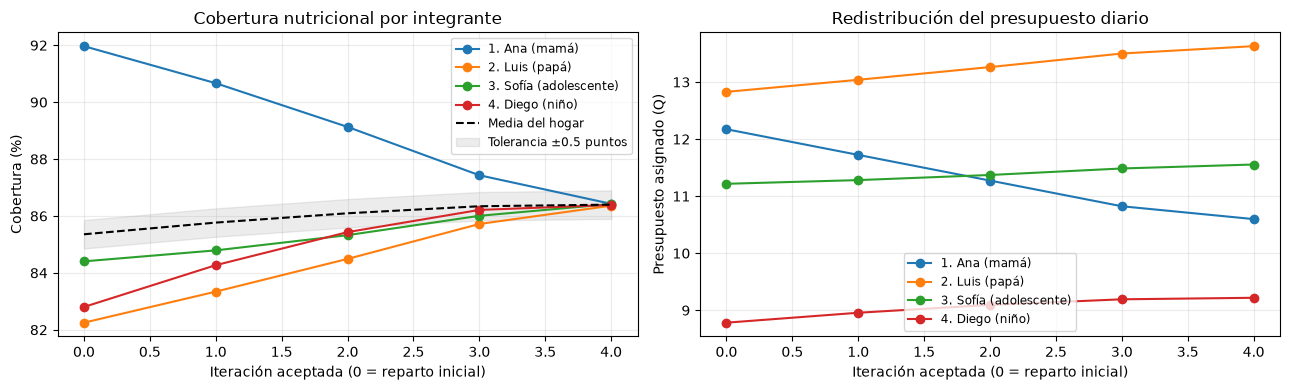

: 

In [ ]:
# Evolución de la cobertura y del presupuesto en los pasos aceptados.
import matplotlib.pyplot as plt

historial = consulta_hogar.get('historial_ajuste', pd.DataFrame())
if not historial.empty and historial['media_hogar_pct'].notna().all():
    fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
    for perfil_id, filas in historial.groupby('perfil_id', sort=False):
        etiqueta = f"{perfil_id}. {filas['persona'].iloc[0]}"
        ejes[0].plot(filas['iteracion'], filas['cobertura_pct'], marker='o', label=etiqueta)
        ejes[1].plot(filas['iteracion'], filas['presupuesto_q'], marker='o', label=etiqueta)
    medias = historial.groupby('iteracion')['media_hogar_pct'].first()
    tolerancia = consulta_hogar['tolerancia_pp']
    ejes[0].plot(medias.index, medias.values, color='black', linestyle='--', label='Media del hogar')
    ejes[0].fill_between(medias.index, medias.values - tolerancia, medias.values + tolerancia,
                        color='gray', alpha=0.15, label=f'Tolerancia ±{tolerancia:g} puntos')
    ejes[0].set(title='Cobertura nutricional por integrante', ylabel='Cobertura (%)')
    ejes[1].set(title='Redistribución del presupuesto diario', ylabel='Presupuesto asignado (Q)')
    for eje in ejes:
        eje.set_xlabel('Iteración aceptada (0 = reparto inicial)')
        eje.grid(alpha=0.25)
        eje.legend(fontsize='small')
    fig.tight_layout()
    plt.show()
else:
    print('No hay un historial completo de coberturas para graficar.')
